## Assignment 8

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("housing.csv")
df.head()

,Crime_rate,zn,indus,chas,nox,rm,Age,Distance,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
df.columns

Index(['Crime_rate', 'zn', 'indus', 'chas', 'nox', 'rm', 'Age', 'Distance',
       'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Crime_rate  506 non-null    float64
 1   zn          506 non-null    float64
 2   indus       506 non-null    float64
 3   chas        506 non-null    int64  
 4   nox         506 non-null    float64
 5   rm          501 non-null    float64
 6   Age         506 non-null    float64
 7   Distance    506 non-null    float64
 8   rad         506 non-null    int64  
 9   tax         506 non-null    int64  
 10  ptratio     506 non-null    float64
 11  b           506 non-null    float64
 12  lstat       506 non-null    float64
 13  medv        506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [5]:
df.isnull().sum()

Crime_rate    0
zn            0
indus         0
chas          0
nox           0
rm            5
Age           0
Distance      0
rad           0
tax           0
ptratio       0
b             0
lstat         0
medv          0
dtype: int64

In [6]:
rm_median = df["rm"].median()

In [7]:
df['rm'] = df["rm"].fillna(rm_median)

In [8]:
df.isnull().sum()

Crime_rate    0
zn            0
indus         0
chas          0
nox           0
rm            0
Age           0
Distance      0
rad           0
tax           0
ptratio       0
b             0
lstat         0
medv          0
dtype: int64

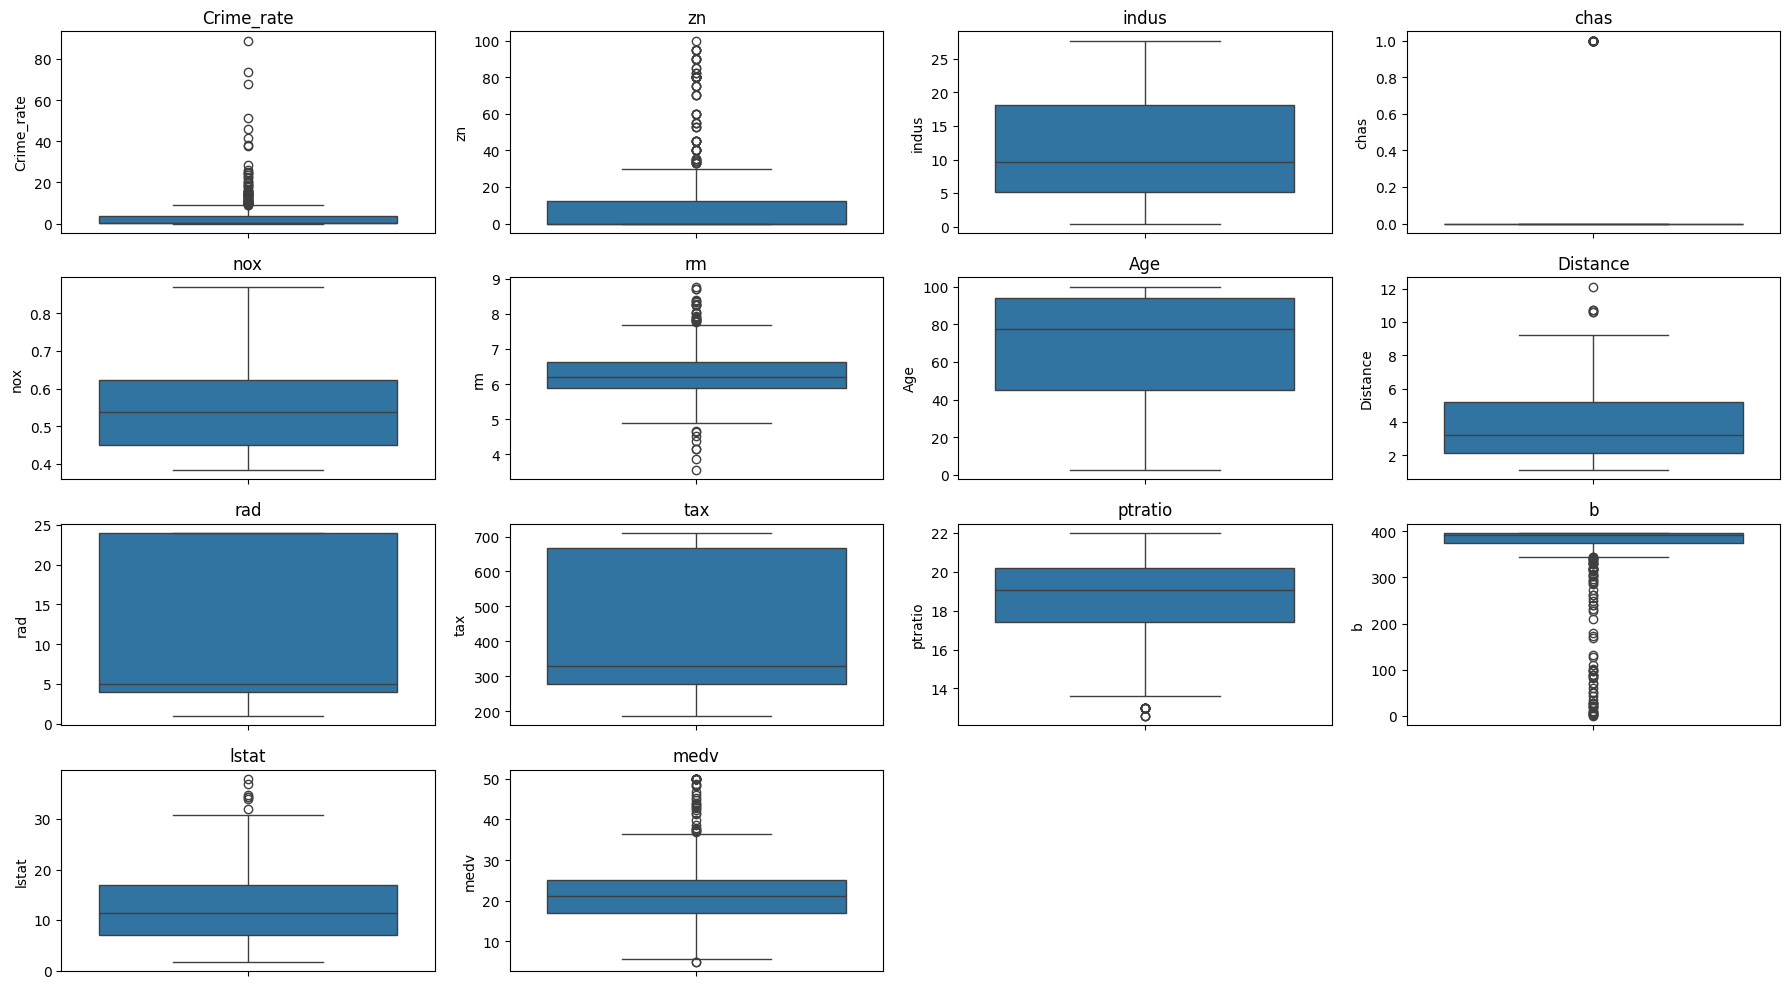

In [9]:
plt.figure(figsize=(18,10))

for i, col in enumerate(df.columns, 1):
    plt.subplot(4, 4, i)   # 4 rows, 4 columns
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

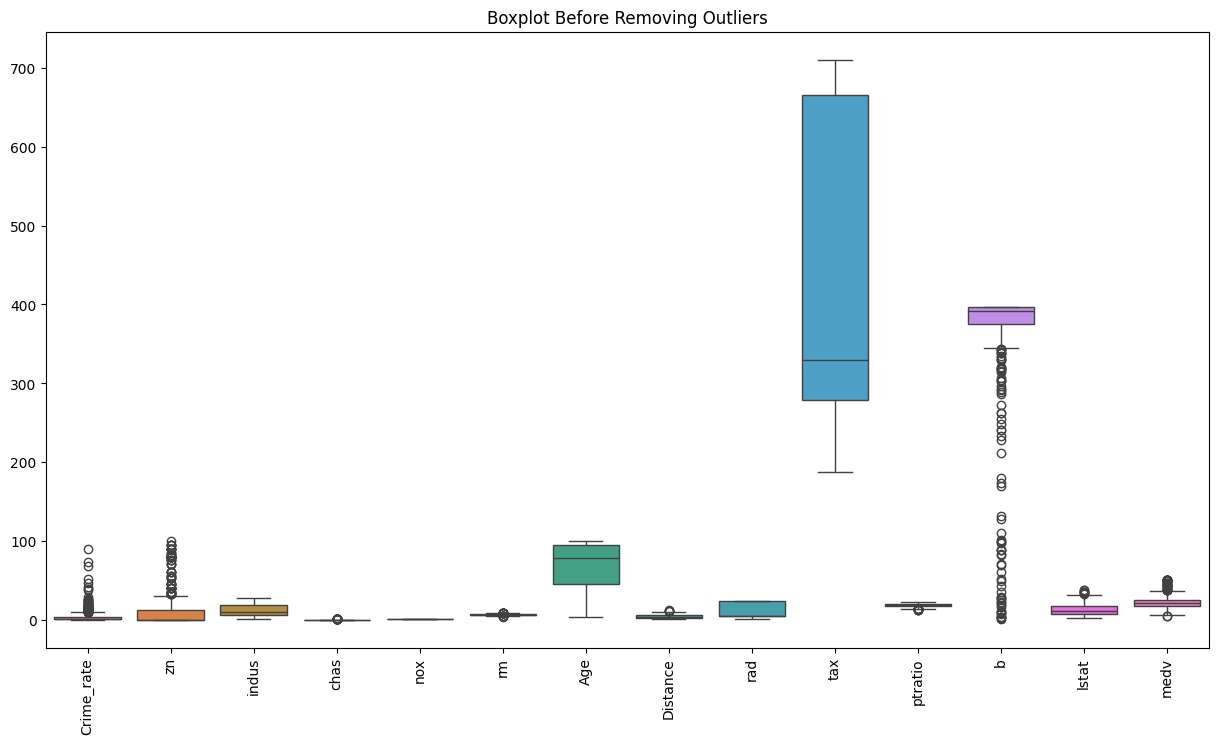

In [10]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot Before Removing Outliers")
plt.show()

In [11]:
# Make a copy of dataset
df_capped = df.copy()

for col in df_capped.columns:
    

    # Calculate Q1, Q3 and IQR
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define lower and upper limits
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Apply capping
    df_capped[col] = df_capped[col].clip(lower_limit, upper_limit)

# Check result
print("Original Shape:", df.shape)
print("Shape After Capping:", df_capped.shape)
df_capped.head()

Original Shape: (506, 14)
Shape After Capping: (506, 14)


,Crime_rate,zn,indus,chas,nox,rm,Age,Distance,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


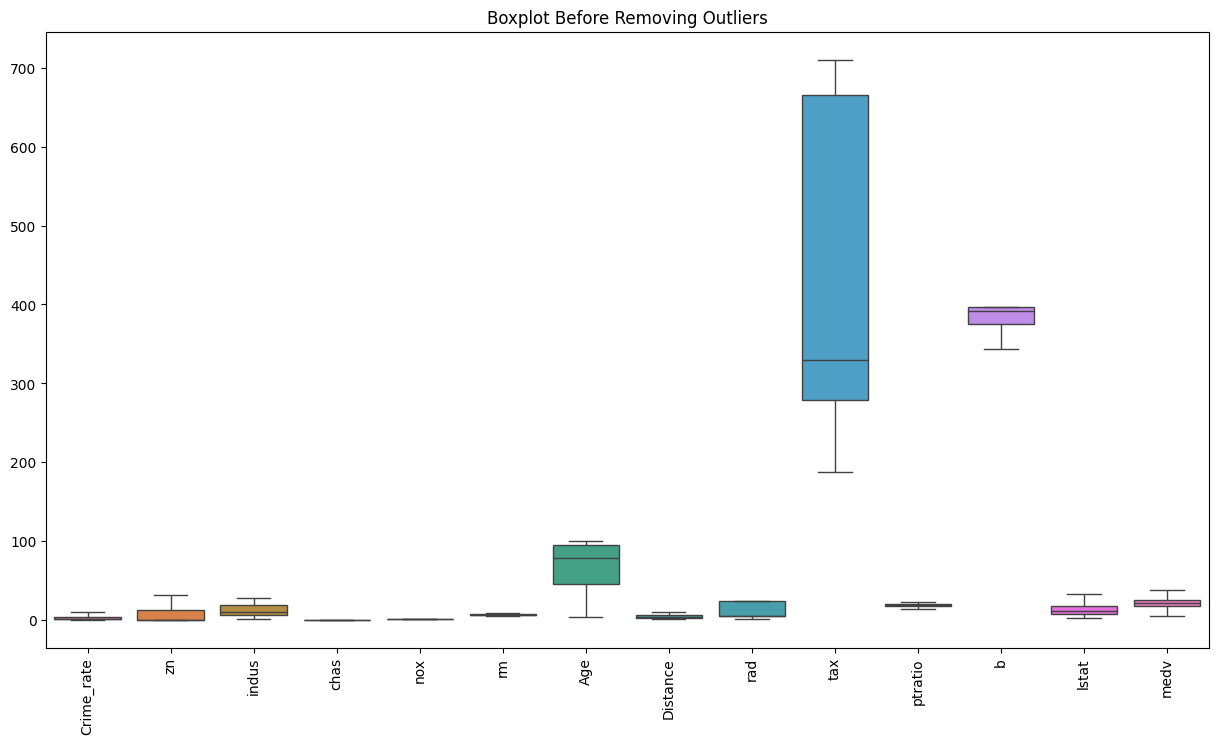

In [12]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df_capped)
plt.xticks(rotation=90)
plt.title("Boxplot Before Removing Outliers")
plt.show()

In [13]:
df = df_capped

In [14]:
df.tail()

,Crime_rate,zn,indus,chas,nox,rm,Age,Distance,rad,tax,ptratio,b,lstat,medv
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273,21.0,396.90,7.88,11.9


In [15]:
df.shape

(506, 14)

In [16]:
df.columns

Index(['Crime_rate', 'zn', 'indus', 'chas', 'nox', 'rm', 'Age', 'Distance',
       'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

In [17]:
df.isnull().sum()

Crime_rate    0
zn            0
indus         0
chas          0
nox           0
rm            0
Age           0
Distance      0
rad           0
tax           0
ptratio       0
b             0
lstat         0
medv          0
dtype: int64

#### Correlation heatmap

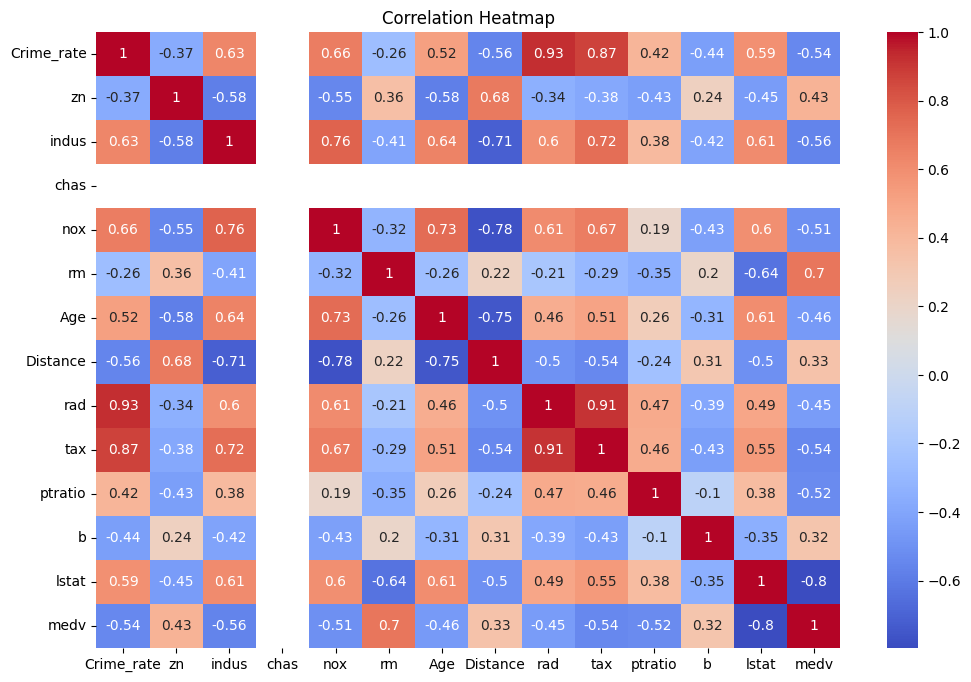

In [18]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Define features and target

In [19]:
# Step 6: Define Features and Target

X = df.drop("medv", axis=1)   # Drop target column
y = df["medv"]               # Target variable

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (506, 13)
Shape of y: (506,)


### Train-Test Split

In [20]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42     # For reproducibility
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (404, 13)
Testing Data Shape: (102, 13)


### Create and train regression model

In [21]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


### Model Coefficients

In [22]:
#intercept
print("Intercept: ",model.intercept_)

#coefficients
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficients":model.coef_
})

coeff_df

Intercept:  27.4892410372344


,Feature,Coefficients
0,Crime_rate,-6.550695e-01
1,zn,3.110715e-02
2,indus,2.098586e-03
3,chas,-8.298917e-15
4,nox,-1.178294e+01
5,rm,3.462616e+00
6,Age,-1.352316e-02
7,Distance,-1.131909e+00
8,rad,3.145939e-01
9,tax,-8.851671e-03


### Make Predictions

In [23]:
y_pred = model.predict(X_test)

# compare actual vs predicted
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head()

,Actual,Predicted
173,23.6,28.106847
274,32.4,31.886056
491,13.6,15.070924
72,22.8,25.083156
452,16.1,18.055544


### Evaluate the model

In [24]:
# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error: ", mse)

# Root Mean Squared Error
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

# r2 score  -    higher the r^2, better is the model fit
r2 = r2_score(y_test, y_pred)
print("R2 SCORE: ", r2)
# if r^2 = 0.75 , then model explains 75% of variation.

Mean Squared Error:  12.092937228730921
Root Mean Squared Error: 3.4774900760075393
R2 SCORE:  0.7528267842076606


### Visualization

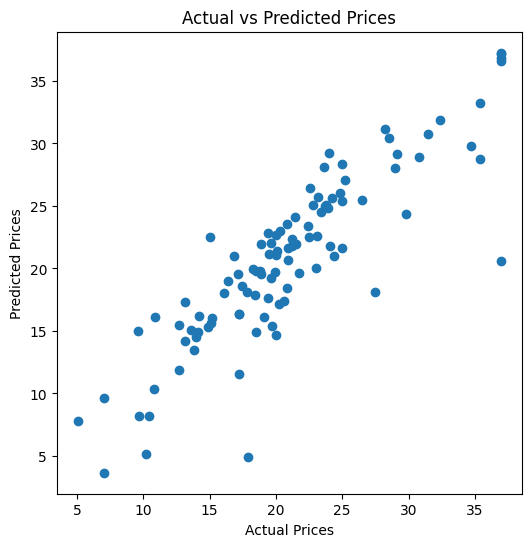

In [25]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

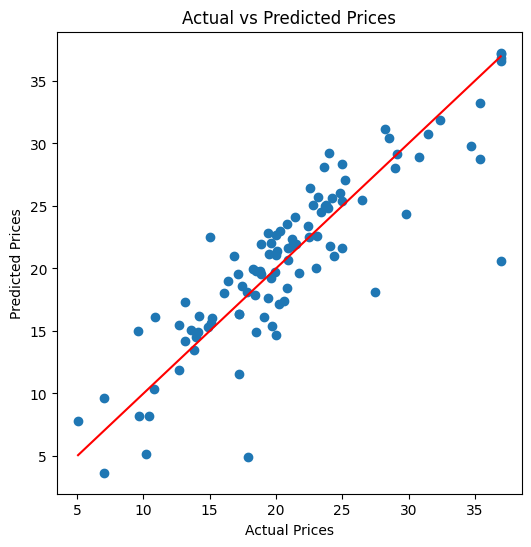

In [26]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()